In [1]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the classic Iris dataset
iris = load_iris()

# Create a DataFrame for data handling
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: iris.target_names[0],
                                       1: iris.target_names[1],
                                       2: iris.target_names[2]})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
print(df.head())

Dataset Shape: (150, 6)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species species_name  
0        0       setosa  
1        0       setosa  
2        0       setosa  
3        0       setosa  
4        0       setosa  


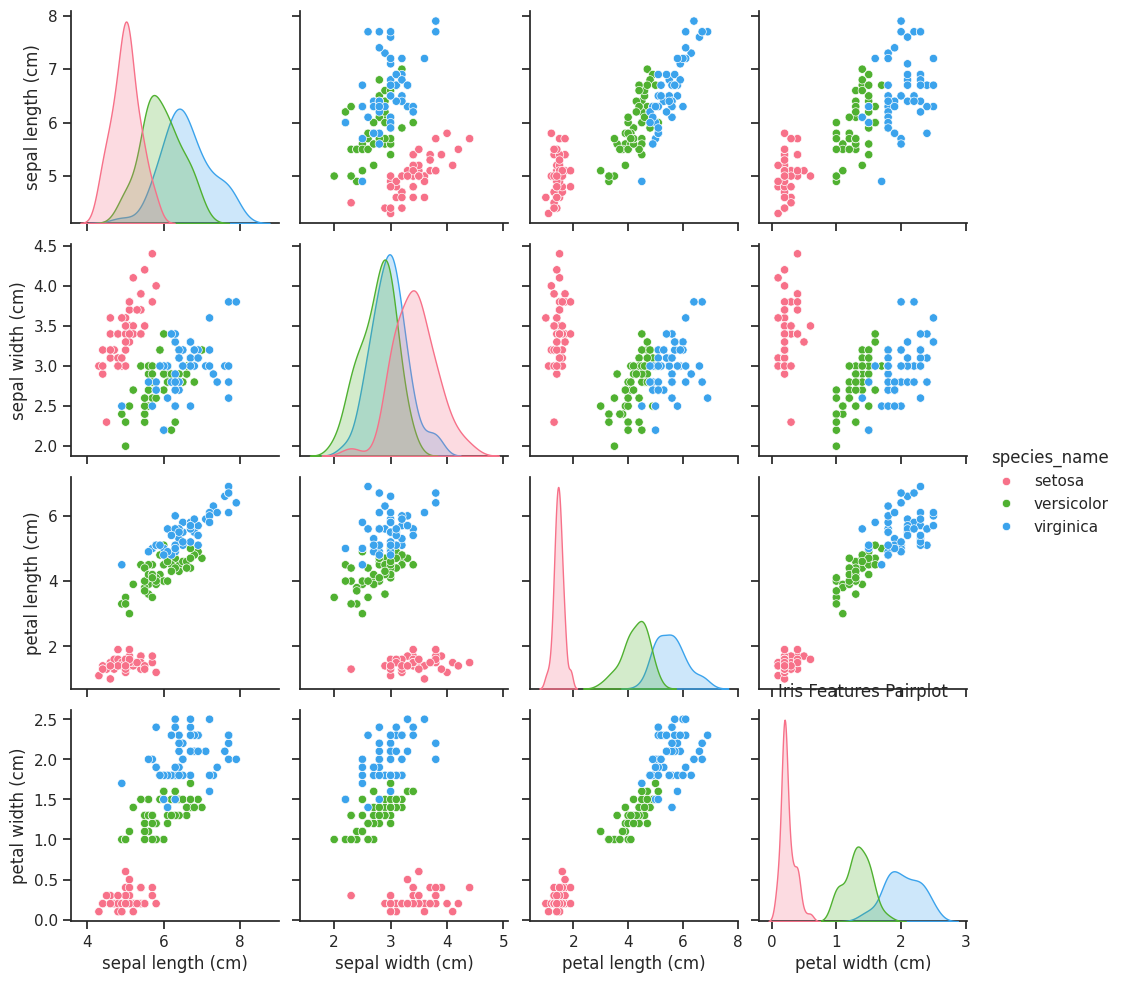

In [3]:
# Graph 1: Pairplot visualization to see how features separate the species
sns.set_theme(style="ticks")
sns.pairplot(df.drop(columns=['species']), hue='species_name', palette='husl')
plt.title("Iris Features Pairplot", y=1.02)
plt.show()

In [4]:
# Separate independent features (X) and target variable (y)
X = df.drop(columns=['species', 'species_name'])
y = df['species']

# Split data into training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


In [5]:
# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [6]:
# Make predictions on the test dataset
y_pred = log_reg_model.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"Model Accuracy: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(class_report)

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



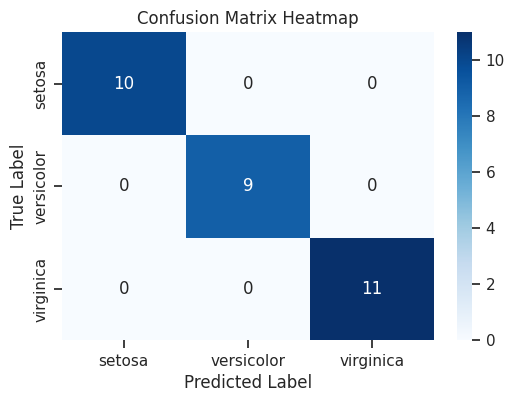

In [7]:
# Graph 2: Plotting Confusion Matrix using Seaborn Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [8]:
# Test with a new sample flower measurement [sepal_length, sepal_width, petal_length, petal_width]
new_flower = [[5.1, 3.5, 1.4, 0.2]]
new_flower_scaled = scaler.transform(new_flower)

# Predict the class and get probabilities
prediction = log_reg_model.predict(new_flower_scaled)
probabilities = log_reg_model.predict_proba(new_flower_scaled)

predicted_species = iris.target_names[prediction[0]]
confidence = probabilities[0][prediction[0]] * 100

print(f"Prediction Result: The flower belongs to species -> '{predicted_species}'")
print(f"Confidence Score: {confidence:.2f}%")

Prediction Result: The flower belongs to species -> 'setosa'
Confidence Score: 97.90%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
